In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium.vector import VectorEnv
import tqdm
from torch.nn import Sequential, ReLU, Linear, Softmax, Module
import torch
from torch.nn import Linear, ReLU, Sequential, Module, Softmax
from torch.distributions.categorical import Categorical
from torch._prims_common import DeviceLikeType
from collections import deque
import tqdm
import matplotlib.pyplot as plt
from numpy import float32

In [52]:
## Helper functions

def plot_rewards(rewards, n_episodes, window_size = 100):
  rolling_rewards = pd.Series(rewards[:n_episodes]).rolling(window=window_size).mean()
  plt.plot(rolling_rewards)
  plt.xlabel("Episode")
  plt.ylabel("Smoothed Total Reward")
  plt.title(f"Smoothed reward accumulation over {n_episodes} episodes. Window size: {window_size}")
  plt.show()

In [71]:
class QL:
  def __init__(self, observation_space_size: int, action_space_size: int, alpha = 0.9, gamma = 0.9, epsilon = 1, epsilon_decay = 0.0001) -> None:
    self.alpha = alpha # learning rate
    self.gamma = gamma # discount factor
    self.epsilon = epsilon # epsilon greedy start
    self.epsilon_decay = epsilon_decay # epsilon greedy decay
    self.q = np.zeros((observation_space_size, action_space_size))
    self.rng = np.random.default_rng()

  def train(self, env, n_episodes = 100):
    total_rewards = np.zeros(n_episodes, dtype=np.float32)
    for ep in range(n_episodes):
      total_rewards[ep] = self._train_step(env)
    return total_rewards

  def _train_step(self, env: gym.Env):
    state = env.reset()[0]
    episode_over = False
    reward = 0
    while not (episode_over):
      action = self._choose_action_train(env, state)
      new_state, reward, terminated, truncated, _info = env.step(action)
      self._q_update(state, action, reward, new_state)
      episode_over = terminated or truncated
      state = new_state
    self.epsilon = max(self.epsilon - self.epsilon_decay, 0)
    return float(reward)

  def _q_update(self, state, action, reward, new_state):
    self.q[state,action] = self.q[state,action] + self.alpha * (
      reward + self.gamma * np.max(self.q[new_state,:]) - self.q[state,action]
    )

  def _choose_action_train(self, env: gym.Env, state):
    if self.rng.random() < self.epsilon:
      return env.action_space.sample()
    else:
      return np.argmax(self.q[state, :])

  def choose_action(self, state):
    return np.argmax(self.q[state, :])

  def load_model(self, path:str) -> None:
    self.q = np.load(path)

  def save_model(self, path:str) -> None:
    np.save(path, self.q)

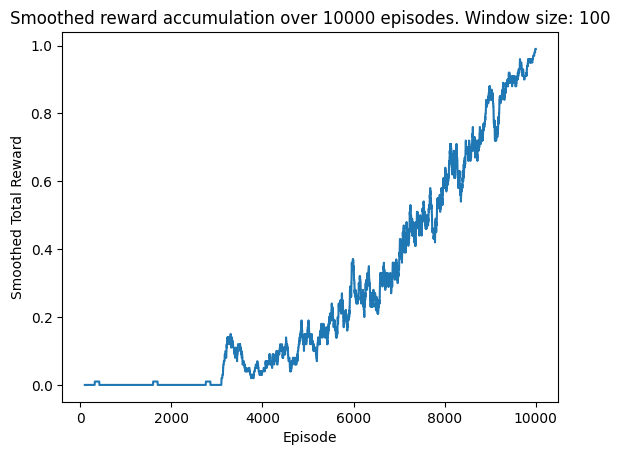

In [84]:
N_EPISODES = 10000
IS_SLIPPERY = False

env = gym.make('FrozenLake-v1', map_name="8x8", is_slippery=IS_SLIPPERY, render_mode=None)
ql = QL(env.observation_space.n, env.action_space.n)
rewards = ql.train(env, N_EPISODES)
plot_rewards(rewards, N_EPISODES)

In [85]:
N_TEST_RUNS = 100
RENDER = None # set to "human" to enable game UI

env = gym.make('FrozenLake-v1', map_name="8x8", is_slippery=IS_SLIPPERY, render_mode=RENDER)
test_reward = 0
for _ in range(N_TEST_RUNS):
  terminated = False
  truncated = False
  state = env.reset()[0]
  while not(terminated or truncated):
    state, r, terminated, truncated, _i = env.step(ql.choose_action(state))
    test_reward += float(r)
print(f"{N_TEST_RUNS} games played")
print(f"Average reward per game: {test_reward/N_TEST_RUNS}")

100 games played
Average reward per game: 1.0


In [86]:
ql.save_model("weights/frozenlake_q.npy")

In [63]:
STATE_MAX_VALUES = [2.4, 3.0, 0.21, 3.0]

class QFA:
  def __init__(self, observation_space_size: int, action_space_size: int, alpha = 0.05, gamma = 0.95, epsilon = 1, epsilon_decay = 0.995, min_epsilon = 0.05) -> None:
    self.alpha = alpha # learning rate
    self.gamma = gamma # discount factor
    self.epsilon = epsilon # epsilon greedy start
    self.epsilon_decay = epsilon_decay # epsilon greedy decay
    self.min_epsion = min_epsilon # minimal epsilon value
    self.early_cutoff = 10
    self.rng = np.random.default_rng()
    self.w = np.zeros((observation_space_size, action_space_size), dtype=np.float64)
    self.n_actions = action_space_size
    self.episodes = 0

  def train(self, env: gym.Env, n_episodes: int):
    rewards = np.zeros(n_episodes, dtype=float32)
    pbar = tqdm.trange(n_episodes, desc="Training", unit="episode")
    self.episodes = n_episodes
    cutoff_counter = 0
    ep = 0
    for ep in pbar:
      rewards[ep] = self._train_step(env)
      if rewards[ep] == 500:
        cutoff_counter += 1
      else:
        cutoff_counter = 0
      pbar.set_postfix({"reward": f"{rewards[ep]:.1f}", "epsilon": f"{self.epsilon:.3f}", "500_streak": cutoff_counter})
      if cutoff_counter == self.early_cutoff:
        self.episodes = ep + 1
        break
    return rewards[:ep]

  def choose_action(self, state):
    state = self._normalize_state(state)
    return self._best_q_action(state)

  def save_model(self, path):
    np.save(path, self.w)

  def load_model(self, path):
    self.w = np.load(path)

  def _train_step(self, env: gym.Env):
    episode_reward = 0.0
    state = self._normalize_state(env.reset()[0])
    while True:
      action = self._choose_action_train(env, state)
      new_state, reward, terminated, truncated, _info = env.step(action)
      episode_reward += float(reward)
      new_state = self._normalize_state(new_state)
      self.q_update(state, action, reward, new_state)
      if (terminated or truncated):
        break
      state = new_state
    self.epsilon = max(self.epsilon * self.epsilon_decay, self.min_epsion)
    return episode_reward

  def _q(self, state, action):
    state = np.array(state)
    return self.w[:, action] @ state

  def _best_q_action(self, state):
    return np.argmax(np.array([self._q(state, action) for action in range(self.n_actions)]))

  def _best_q_value(self, state):
    return np.max(np.array([self._q(state, action) for action in range(self.n_actions)]))

  def _normalize_state(self, state):
      state = np.array(state, dtype=np.float32)
      normed = state / STATE_MAX_VALUES
      return np.clip(normed, -1, 1)

  def q_update(self, state, action, reward, new_state):
    qsa = self._q(state, action)
    target = reward + self.gamma * self._best_q_value(new_state)
    error = target - qsa
    self.w[:, action] = self.w[:, action] + self.alpha * error * np.array(state)

  def _choose_action_train(self, env: gym.Env, state):
    if self.rng.random() < self.epsilon:
      return env.action_space.sample()
    else:
      return self._best_q_action(state)

Training:  22%|██▏       | 781/3500 [00:00<00:01, 1725.82episode/s, reward=500.0, epsilon=0.050, 500_streak=10]


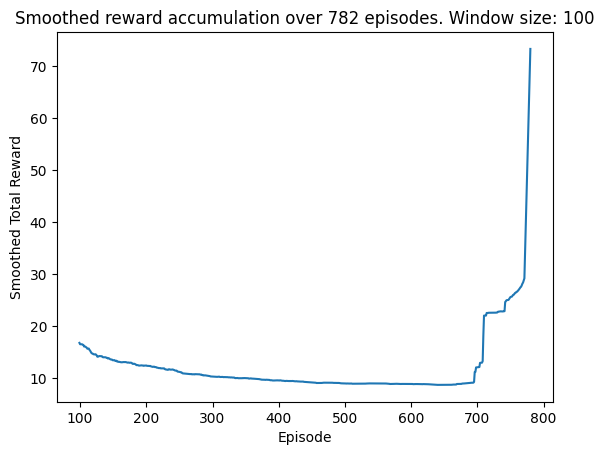

In [64]:
N_EPISODES = 3500

env = gym.make("CartPole-v1", render_mode=None)
qfa = QFA(env.observation_space.shape[0], env.action_space.n)
rewards = qfa.train(env, N_EPISODES)
plot_rewards(rewards, qfa.episodes)

In [65]:
N_TEST_RUNS = 100
RENDER = None # set to "human" to enable game UI

env = gym.make("CartPole-v1", render_mode=RENDER)
test_reward = 0
for _ in range(N_TEST_RUNS):
  terminated = False
  truncated = False
  state = env.reset()[0]
  while not(terminated or truncated):
    state, r, terminated, truncated, _i = env.step(qfa.choose_action(state))
    test_reward += float(r)
print(f"{N_TEST_RUNS} games played")
print(f"Average reward per game: {test_reward/N_TEST_RUNS}")

100 games played
Average reward per game: 500.0


In [83]:
qfa.save_model("weights/pole_qfa.npy")

In [59]:
class Actor(Module):
  def __init__(self, input_dim:int, output_dim:int, *args, **kwargs) -> None:
    super().__init__(*args, **kwargs)
    self.nn = Sequential(
      Linear(input_dim, 64),
      ReLU(),
      Linear(64, output_dim),
      Softmax(1)
    )
  def forward(self, x):
    return self.nn(x)

class Critic(Module):
  def __init__(self, input_dim:int, *args, **kwargs) -> None:
    super().__init__(*args, **kwargs)
    self.nn = Sequential(
      Linear(input_dim, 64),
      ReLU(),
      Linear(64, 1)
    )
  def forward(self, x):
    return self.nn(x)

In [60]:
class AC:
  def __init__(self, observation_space_size: int, action_space_size: int, actor_learning_rate = 5e-4, critic_learning_rate = 3e-3, gamma = 0.99, device: str = "mps"):
    self.device = device
    self.actor = Actor(observation_space_size, action_space_size).to(self.device)
    self.critic = Critic(observation_space_size).to(self.device)
    self.a_opt = torch.optim.Adam(self.actor.parameters(), lr=actor_learning_rate)
    self.c_opt = torch.optim.Adam(self.critic.parameters(), lr=critic_learning_rate)
    self.gamma = gamma
    self.cutoff_counter = 0
    self.early_cutoff = 10
    self.episodes = 0

  def train(self, env: gym.Env, n_episodes: int):
    rewards = np.zeros(n_episodes, dtype=np.float32)
    pbar = tqdm.trange(n_episodes, desc="Training", unit="episode")
    ep = 0
    self.episodes = n_episodes
    for ep in pbar:
      r = self._train_step(env)
      rewards[ep] = r
      self.cutoff_counter = self.cutoff_counter + 1 if r == 500.0 else 0
      if (self.cutoff_counter == self.early_cutoff):
        self.episodes = ep
        break
    return rewards[:ep]

  def _train_step(self, env: gym.Env):
    state = env.reset()[0]
    episode_reward = 0.0
    while True:
      state_tensor = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
      action_probs = self.actor(state_tensor)
      action = np.random.choice(env.action_space.n, p=action_probs.cpu().detach().numpy()[0])
      next_state, reward, terminated, truncated, _ = env.step(action)
      episode_reward += float(reward)

      next_state_tensor = torch.tensor(next_state, dtype=torch.float32, device=self.device).unsqueeze(0)

      state_v = self.critic(state_tensor)
      if terminated or truncated:
          next_state_v = torch.tensor(0.0, dtype=torch.float32, device=self.device)
      else:
          next_state_tensor = torch.tensor(next_state, dtype=torch.float32, device=self.device).unsqueeze(0)
          with torch.no_grad():
              next_state_v = self.critic(next_state_tensor)

      advantage = reward + self.gamma * next_state_v - state_v

      actor_loss = -torch.log(action_probs[0, action] + 1e-8) * advantage
      critic_loss = advantage.pow(2)

      self.a_opt.zero_grad()
      self.c_opt.zero_grad()

      total_loss = (actor_loss + critic_loss)
      total_loss.backward()

      self.a_opt.step()
      self.c_opt.step()

      state = next_state
      if (terminated or truncated):
        break
    return episode_reward

  def choose_action(self, state):
    state_tensor = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
    with torch.no_grad():
      action_probs_tensor = self.actor(state_tensor)
      action_probs = action_probs_tensor.cpu().numpy()[0]
    return np.argmax(action_probs)

  def save_model(self, path="ac_path.pth"):
    torch.save(self.actor.state_dict(), path)

  def load_model(self, path="ac_path.pth"):
    self.actor.load_state_dict(torch.load(path))
    self.actor.eval()

Training:  31%|███▏      | 314/1000 [01:14<02:42,  4.21episode/s]


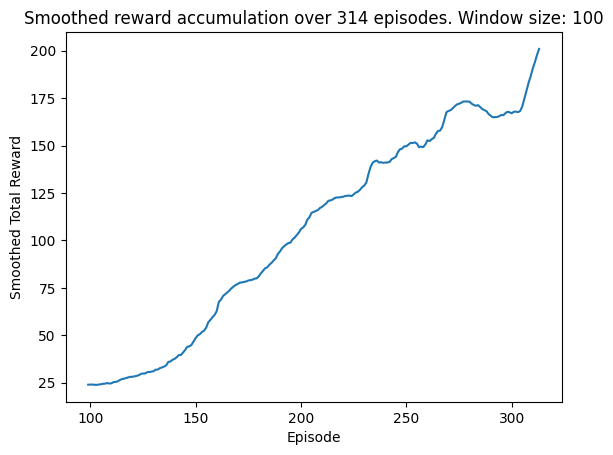

In [61]:
N_EPISODES = 1000

env = gym.make("CartPole-v1", render_mode=None)
ac = AC(env.observation_space.shape[0], env.action_space.n)
rewards = ac.train(env, N_EPISODES)
plot_rewards(rewards, ac.episodes)

In [62]:
N_TEST_RUNS = 100
RENDER = None # set to "human" to enable game UI

env = gym.make("CartPole-v1", render_mode=RENDER)
test_reward = 0
for _ in range(N_TEST_RUNS):
  terminated = False
  truncated = False
  state = env.reset()[0]
  while not(terminated or truncated):
    state, r, terminated, truncated, _i = env.step(ac.choose_action(state))
    test_reward += float(r)
print(f"{N_TEST_RUNS} games played")
print(f"Average reward per game: {test_reward/N_TEST_RUNS}")

100 games played
Average reward per game: 500.0


In [82]:
ac.save_model("weights/pole_ac.pth")

In [66]:
class QNetwork(torch.nn.Module):
  def __init__(self, input_dim: int, output_dim: int) -> None:
    super().__init__()
    self.nn = Sequential(
      Linear(input_dim, 128),
      ReLU(),
      Linear(128, 128),
      ReLU(),
      Linear(128, output_dim)
    )

  def forward(self, x):
    return self.nn(x)

class ReplayBuffer:
  def __init__(self, batch_size: int, buffer_size: int) -> None:
    self.batch_size = batch_size
    self.buffer = deque(maxlen=buffer_size)

  def push(self, state, action, reward, next_state, done):
    self.buffer.append((state, action, reward, next_state, done))

  def sample(self):
    indices = np.random.randint(0, len(self.buffer), size=self.batch_size)
    batch = [self.buffer[i] for i in indices]
    states, actions, rewards, next_states, dones = map(np.array, zip(*batch))
    return states, actions, rewards, next_states, dones
  def __len__(self):
      return len(self.buffer)

In [68]:
class DQL:
  def __init__(self, observation_space_size: int, action_space_size: int, epsilon = 1, epsilon_decay = 0.001, min_epsilon = 0.08, batch_size: int = 64, buffer_size: int = 100_000, gamma: float = 0.99, target_update_freq = 1000, device: str = "mps") -> None:
    self.gamma = gamma
    self.epsilon = epsilon
    self.epsilon_decay = epsilon_decay
    self.min_epsilon = min_epsilon
    self.device = torch.device(device)
    self.rng = np.random.default_rng()
    self.target_update_freq = target_update_freq

    self.replay = ReplayBuffer(batch_size=batch_size, buffer_size=buffer_size)
    self.loss_fn = torch.nn.MSELoss()
    self.q_online = QNetwork(observation_space_size, action_space_size).to(device)
    self.q_target = QNetwork(observation_space_size, action_space_size).to(device)
    self.optimizer = torch.optim.Adam(self.q_online.parameters(), lr=1e-3)
    self.q_target.load_state_dict(self.q_online.state_dict())
    self.q_target.eval()

    self.step_count = 0
    self.step_milestone = target_update_freq

  def train(self, env: gym.Env, n_episodes = 100):
    pbar = tqdm.trange(n_episodes, desc="Training", unit="episode")
    rewards = np.zeros(n_episodes, dtype=np.float32)
    for ep in pbar:
      r = self._train_step(env)
      rewards[ep] = r
      pbar.set_postfix({"episode": ep, "reward": r})
      if self.step_count >= self.step_milestone:
        self.q_target.load_state_dict(self.q_online.state_dict())
        self.step_count = 0
    return rewards

  def _train_step(self, env: gym.Env):
    state = env.reset()[0]
    episode_reward = 0
    done = False
    while not done:
      action = self._choose_action_train(state, env)
      next_state, reward, terminated, truncated, _ = env.step(action)
      self.step_count += 1
      done = terminated or truncated
      self.replay.push(state, action, reward, next_state, done)
      state = next_state
      episode_reward += float(reward)

      if (len(self.replay) < self.replay.batch_size):
        continue
      states, actions, rewards, next_states, dones = self.replay.sample()
      states = torch.tensor(states, dtype=torch.float32).to(self.device)
      actions = torch.tensor(actions, dtype=torch.int64).to(self.device).unsqueeze(1)
      rewards = torch.tensor(rewards, dtype=torch.float32).to(self.device).unsqueeze(1)
      next_states = torch.tensor(next_states, dtype=torch.float32).to(self.device)
      dones = torch.tensor(dones, dtype=torch.float32).to(self.device).unsqueeze(1)

      q_values = self.q_online(states).gather(1, actions)

      with torch.no_grad():
        next_actions = self.q_online(next_states).argmax(dim=1, keepdim=True)
        next_q_values = self.q_target(next_states).gather(1, next_actions)
        targets = rewards + self.gamma * (1 - dones) * next_q_values

      loss = self.loss_fn(q_values, targets)

      self.optimizer.zero_grad()
      loss.backward()
      self.optimizer.step()
    self.epsilon = max(self.min_epsilon, self.epsilon - self.epsilon_decay)
    return episode_reward

  def _choose_action_train(self, state, env: gym.Env):
      if self.rng.random() < self.epsilon:
        return env.action_space.sample()
      state_t = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
      with torch.no_grad():
          q_values = self.q_online(state_t)
      return q_values.argmax(dim=1).item()

  def choose_action(self, state):
      state_t = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
      with torch.no_grad():
          q_values = self.q_online(state_t)
      return q_values.argmax(dim=1).item()

  def save_model(self, path = "q_online.pth"):
    torch.save(self.q_online.state_dict(), path)

  def load_model(self, path = "q_online.pth"):
    self.q_online.load_state_dict(torch.load(path))
    self.q_online.eval()

/Users/are/dev/solo/rl_games/.venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
Training: 100%|██████████| 1000/1000 [12:52<00:00,  1.29episode/s, episode=999, reward=268]  


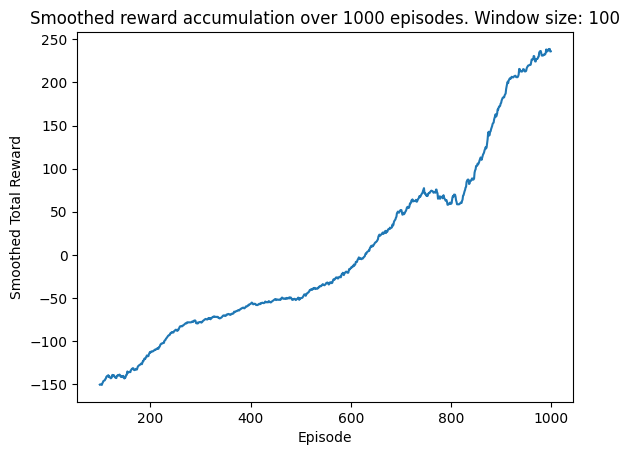

In [69]:
N_EPISODES = 1000

env = gym.make("LunarLander-v3", continuous=False, gravity=-10.0,
      enable_wind=False, wind_power=15.0, turbulence_power=1.5, render_mode = None)
dql = DQL(env.observation_space.shape[0], env.action_space.n)
rewards = dql.train(env, N_EPISODES)
plot_rewards(rewards, N_EPISODES)

In [70]:
N_TEST_RUNS = 100
RENDER = None # set to "human" to enable game UI

env = gym.make("LunarLander-v3", continuous=False, gravity=-10.0,
      enable_wind=False, wind_power=15.0, turbulence_power=1.5, render_mode = None)
test_reward = 0
for _ in range(N_TEST_RUNS):
  terminated = False
  truncated = False
  state = env.reset()[0]
  while not(terminated or truncated):
    state, r, terminated, truncated, _i = env.step(dql.choose_action(state))
    test_reward += float(r)
print(f"{N_TEST_RUNS} games played")
print(f"Average reward per game: {test_reward/N_TEST_RUNS}")

100 games played
Average reward per game: 243.08396640831236


In [81]:
dql.save_model("weights/lunar_dql.pth")